In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from IPython.display import display, Markdown, Math, HTML

import numpy as np
from scipy.constants import epsilon_0, c, hbar
from pyGDM2 import fields

from optomechanics_levitation import particle_properties, rotate_particle, evaluate_incident_field, evaluate_internal_field, evaluate_far_field, force_spectral_density, torque_spectral_density

In [8]:
## PARTICLE PROPERTIES
long_axis = 100.0; long_radius = long_axis / 2.0; aspect_ratio = 2.0; short_radius = long_radius / aspect_ratio # [nm]
wavelength = 1550.0 # [nm]
intensity = 1.0e9 # [W/m^2]

# Discretization step
if aspect_ratio == 2.0:
    mesh_divisions = 35.0
else:
    mesh_divisions = 65.0
step = long_axis / mesh_divisions # [nm]

# x-oriented ellipsoidal particle
ellipsoidal_particle = particle_properties(particle_type="spheroid", material_name="sio2", step_nm=step, mesh="cube",
                                           center=True, R1=long_radius / step - 0.2, R2=short_radius / step - 0.2, R3=short_radius / step - 0.2)

# INTERACTION PARAMETERS
far_field_radius = 1e6 # [nm]

In [9]:
## INCIDENT FIELD AND ANGULAR GRID
environment = {"eps1": 1.0, "eps2": 1.0, "eps3": 1.0, "spacing": 0.0}
E0 = np.sqrt(2 * intensity / (epsilon_0 * c))

def plane_wave_direction(pos, env_dict, wavelength, direction, helicity, returnField="E"):
    """Circular plane wave in vacuum: +1 is RCP and -1 is LCP."""
    direction = np.asarray(direction, dtype=float)
    direction = direction / np.linalg.norm(direction)
    reference = np.array([1.0, 0.0, 0.0]) if abs(direction[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    e1 = reference - np.dot(reference, direction) * direction
    e1 = e1 / np.linalg.norm(e1)
    e2 = np.cross(direction, e1)
    polarization = (e1 + 1j * helicity * e2) / np.sqrt(2)
    electric = np.exp(2j * np.pi / wavelength * (np.asarray(pos) @ direction))[:, None] * polarization
    return electric if returnField.lower() == "e" else np.cross(direction, electric) / c

n_cos_theta = 8
n_azimuth = 16
cos_theta = -1 + (np.arange(n_cos_theta) + 0.5) * 2 / n_cos_theta
azimuth = (np.arange(n_azimuth) + 0.5) * 2 * np.pi / n_azimuth
helicities = (+1, -1)
directions = np.array([[[np.sqrt(1 - u**2) * np.cos(phi), np.sqrt(1 - u**2) * np.sin(phi), u] for phi in azimuth] for u in cos_theta])
torque_map = {name: np.full((2, n_cos_theta, n_azimuth), np.nan) for name in ("total", "spin", "orbital", "mixed")}
prepared_interaction = None

## Angular scan

Each direction represents a separate plane wave at the same intensity. The grid is uniform in $\cos\theta$ and azimuth, so its cells cover equal solid angles. The stored spectral densities use the same division by $2\pi$ as the benchmark notebook. Run the next cell again to resume an interrupted scan while the kernel remains active.

In [10]:
## TORQUE SPECTRAL DENSITY FOR BOTH HELICITIES
from tqdm import tqdm

completed = int(np.isfinite(torque_map["total"]).sum())
with tqdm(total=torque_map["total"].size, initial=completed, desc="Angular scan", unit="beam") as progress:
    for h, helicity in enumerate(helicities):
        for i in range(n_cos_theta):
            for j in range(n_azimuth):
                if np.isfinite(torque_map["total"][h, i, j]):
                    continue

                incident_parameters = dict(wavelength_nm=wavelength, environment=environment, amplitude_v_per_m=E0, direction=tuple(directions[i, j]), helicity=helicity)
                incident_field = evaluate_incident_field(field_generator=plane_wave_direction, positions_nm=ellipsoidal_particle["geometry_nm"], field="E", **incident_parameters)
                interaction = evaluate_internal_field(particle=ellipsoidal_particle if prepared_interaction is None else None, incident_electric_field=incident_field, wavelength_nm=wavelength, environment=environment, prepared_interaction=prepared_interaction)
                prepared_interaction = interaction["prepared_interaction"]

                total, spin, orbital, mixed = torque_spectral_density(interaction, plane_wave_direction, incident_parameters, torque_axis="y", n_theta=64, n_phi=64)
                for name, value in zip(("total", "spin", "orbital", "mixed"), (total, spin, orbital, mixed)):
                    torque_map[name][h, i, j] = value / (2 * np.pi)

                progress.update(1)


Angular scan:   0%|          | 0/256 [00:00<?, ?beam/s]

Angular scan: 100%|██████████| 256/256 [17:24<00:00,  4.08s/beam]


## Results

The mixed contribution to the total is $2S_{\mathrm{mixed}}$. A negative correlation can make the spin or orbital fraction exceed 100%. Each average below is over separate, equally weighted incidence directions; it is not the result of illuminating the particle with all beams simultaneously.

In [16]:
## ANGULAR MEANS AND FRACTIONS
total_map = torque_map["total"]
contributions = {"spin": torque_map["spin"], "orbital": torque_map["orbital"], "correlation": 2 * torque_map["mixed"]}
threshold = 0.01 * np.nanmax(total_map)
fractions = {}
for name, contribution in contributions.items():
    fraction = np.full_like(total_map, np.nan)
    np.divide(100 * contribution, total_map, out=fraction, where=total_map > threshold)
    fractions[name] = fraction

def sci_notation(value, decimals=2):
    mantissa, exponent = f"{value:.{decimals}e}".split("e")
    return rf"{mantissa} \times 10^{{{int(exponent)}}}"

display(Markdown(
    rf"Directions completed: **{np.isfinite(total_map).sum()}/{total_map.size}**. "
    rf"Pointwise percentages are shown where "
    rf"$S_{{\tau\tau}} > 0.01\max S_{{\tau\tau}} "
    rf"= {sci_notation(threshold)}\,\mathrm{{N}}^2\mathrm{{m}}^2/\mathrm{{Hz}}$."
))

rows = [
    r"| Polarization | Mean $S_{\tau\tau}$ [$\mathrm{N}^2\mathrm{m}^2/\mathrm{Hz}$] | Spin | Orbital | Correlation | Directions in histograms |",
    "|---|---:|---:|---:|---:|---:|",
]
for h, label in enumerate(("RCP (σ=+1)", "LCP (σ=−1)")):
    mean_total = np.nanmean(total_map[h])
    shares = [100 * np.nanmean(contributions[name][h]) / mean_total
              for name in ("spin", "orbital", "correlation")]
    valid = np.isfinite(fractions["spin"][h]).sum()
    rows.append(
        rf"| {label} | ${sci_notation(mean_total)}$ | ${shares[0]:.2f}\%$ | ${shares[1]:.2f}\%$ "
        rf"| ${shares[2]:.2f}\%$ | {valid}/{n_cos_theta * n_azimuth} |"
    )
display(Markdown("\n".join(rows)))


Directions completed: **256/256**. Pointwise percentages are shown where $S_{\tau\tau} > 0.01\max S_{\tau\tau} = 8.95 \times 10^{-64}\,\mathrm{N}^2\mathrm{m}^2/\mathrm{Hz}$.

| Polarization | Mean $S_{\tau\tau}$ [$\mathrm{N}^2\mathrm{m}^2/\mathrm{Hz}$] | Spin | Orbital | Correlation | Directions in histograms |
|---|---:|---:|---:|---:|---:|
| RCP (σ=+1) | $6.18 \times 10^{-62}$ | $1211.38\%$ | $1215.04\%$ | $-2326.42\%$ | 128/128 |
| LCP (σ=−1) | $6.18 \times 10^{-62}$ | $1211.38\%$ | $1215.04\%$ | $-2326.42\%$ | 128/128 |

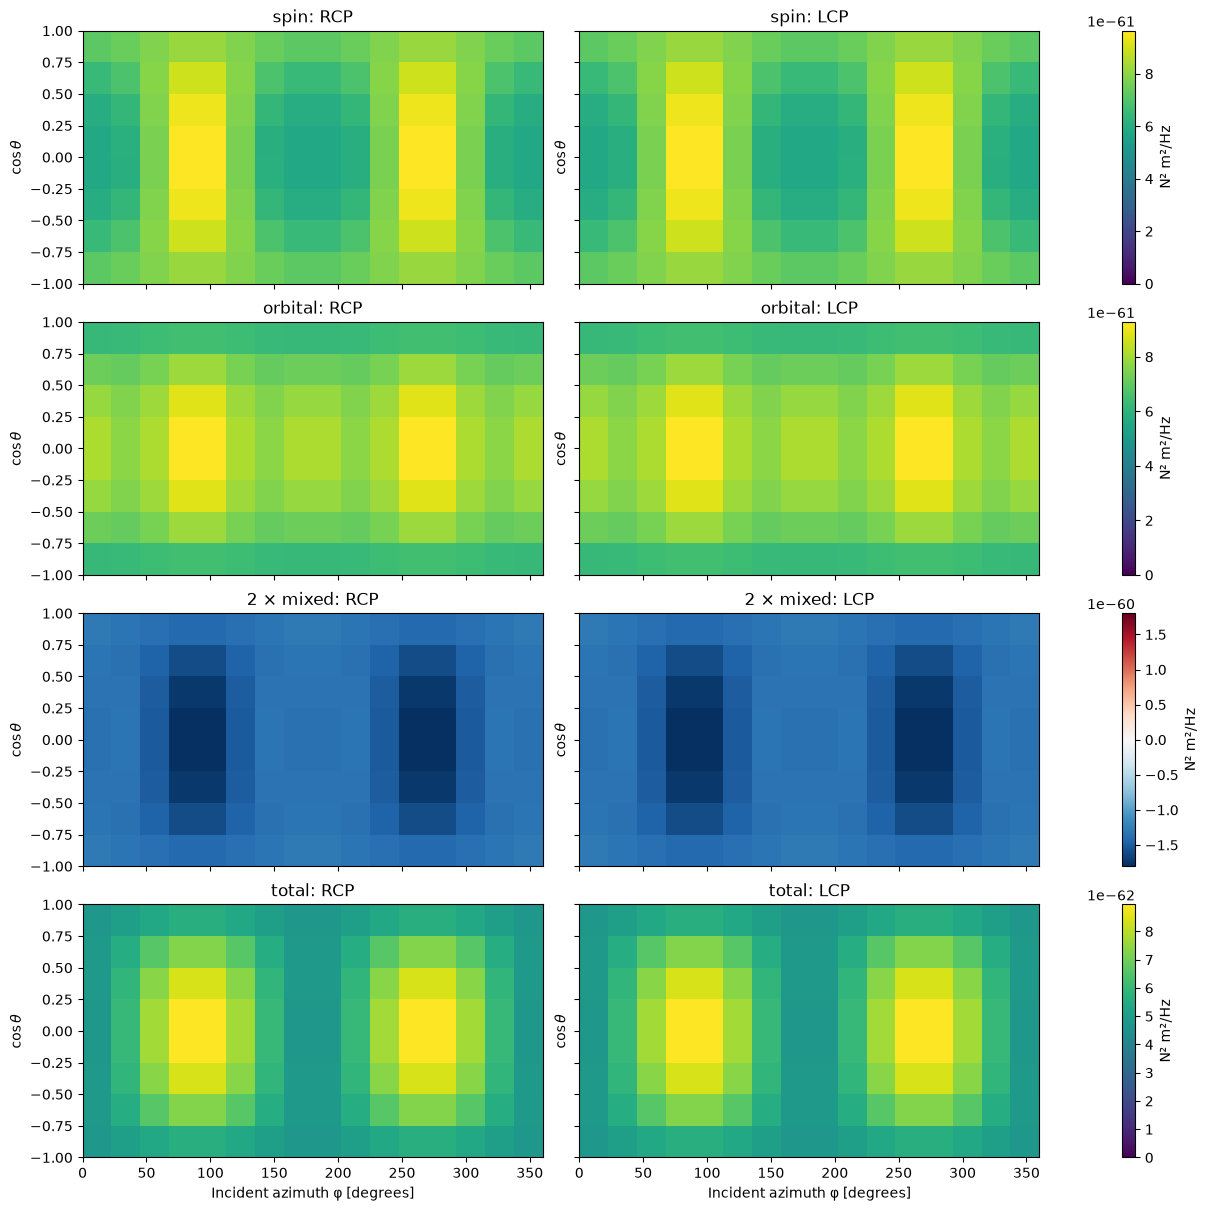

In [12]:
## ANGULAR MAPS: SPECTRAL DENSITY PER INCIDENT DIRECTION
import matplotlib.pyplot as plt

azimuth_edges = np.linspace(0, 360, n_azimuth + 1)
cos_theta_edges = np.linspace(-1, 1, n_cos_theta + 1)
components = [
    ("spin", torque_map["spin"]),
    ("orbital", torque_map["orbital"]),
    ("2 × mixed", 2 * torque_map["mixed"]),
    ("total", torque_map["total"]),
]
fig, axes = plt.subplots(4, 2, figsize=(12, 12), sharex=True, sharey=True, constrained_layout=True)
for row, (label, values) in enumerate(components):
    scale = np.nanmax(np.abs(values)) if row == 2 else np.nanmax(values)
    for h in range(2):
        image = axes[row, h].pcolormesh(
            azimuth_edges, cos_theta_edges, values[h],
            cmap="RdBu_r" if row == 2 else "viridis",
            vmin=-scale if row == 2 else 0,
            vmax=scale,
            shading="auto",
        )
        axes[row, h].set_title(f"{label}: {'RCP' if h == 0 else 'LCP'}")
        axes[row, h].set_ylabel(r"$\cos\theta$")
    fig.colorbar(image, ax=axes[row, :], label="N² m²/Hz")
for ax in axes[-1, :]:
    ax.set_xlabel("Incident azimuth φ [degrees]")
plt.show()

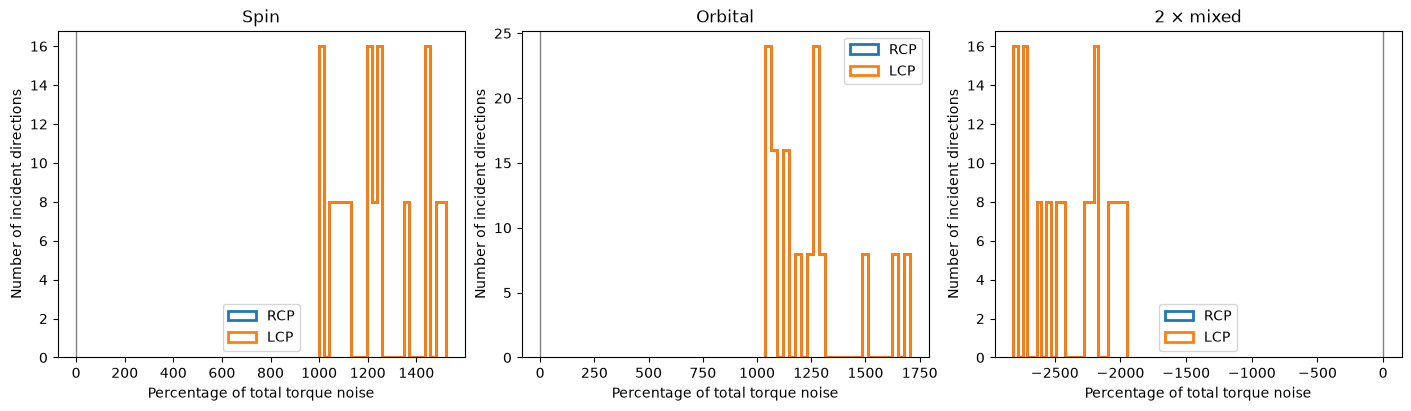

In [13]:
## DISTRIBUTIONS OF THE SIGNED FRACTIONS
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, (name, label) in zip(axes, (
    ("spin", "Spin"),
    ("orbital", "Orbital"),
    ("correlation", "2 × mixed"),
)):
    samples = [fractions[name][h][np.isfinite(fractions[name][h])] for h in range(2)]
    edges = np.histogram_bin_edges(np.concatenate(samples), bins=24)
    for values, polarization in zip(samples, ("RCP", "LCP")):
        ax.hist(values, bins=edges, histtype="step", linewidth=2, label=polarization)
    ax.axvline(0, color="0.5", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("Percentage of total torque noise")
    ax.set_ylabel("Number of incident directions")
    ax.legend()
plt.show()